# ML Challenge -Fraud Detection in Electricity and Gas Consumption 

This notebook covers the different steps involed in the FDEGCC Challenge. 
The data was downloaded form : [zindi.africa](https://zindi.africa/competitions/fraud-detection-in-electricity-and-gas-consumption-challenge/data)

# Phase 1: Data Understanding & EDA

## Step 1: Understanding the Problem

We're working on a fraud detection problem for electricity and gas consumption. We have:

Client data: Customer information (demographics, region, etc.)

Invoice data: Consumption/billing details over time

Target: Binary classification (0 = normal, 1 = fraud)

## Step 2: Initial Setup and Data Loading

In [219]:
## Import Libraries and setup global parameters
# os libs
import os
import sys
from pathlib import Path
# DS libs
import numpy as np
import pandas as pd
import time

# DV libs
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# ML libs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             precision_recall_curve, roc_curve, auc, f1_score,
                             fbeta_score, precision_recall_fscore_support,roc_auc_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Set display options for better visualization
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [220]:
## Pre-Requisites

CURRENT_DIR = Path.cwd()

ROOT_DIR = CURRENT_DIR.parents[0]

DATA_DIR = os.path.join(ROOT_DIR, "data/content")
OUTPUT_DIR = os.path.join(ROOT_DIR, "data/output")

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

In [221]:
## Output Tables
# Set up print options for cleaner output in the console
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

## Plotting
# --- 1. Style Sheet ---
# 'ggplot', 'fivethirtyeight', 'seaborn-v0_8', 'dark_background' are popular.
plt.style.use('seaborn-v0_8') 
# 

# --- 2. Customizing Global Parameters (Fine-tuning) ---

# ====== HELPER FUNCTIONS FOR VIRIDIS VARIATIONS ======

def get_viridis_gradient(n_colors, start=0.2, end=0.8):
    """Get n colors as a gradient from Viridis"""
    return plt.cm.viridis(np.linspace(start, end, n_colors))

def get_viridis_pair(contrast='medium'):
    """Get two contrasting colors from Viridis"""
    if contrast == 'high':
        return [plt.cm.viridis(0.1), plt.cm.viridis(0.9)]  # Dark purple & Yellow
    elif contrast == 'medium':
        return [plt.cm.viridis(0.3), plt.cm.viridis(0.7)]  # Blue & Green-teal
    else:  # low contrast
        return [plt.cm.viridis(0.4), plt.cm.viridis(0.6)]  # Similar colors


# Set a new default color cycle (for lines, bars, etc.)
# Using a Colorblind-Friendly Palette (see Palettes section below)
new_color_cycle = ['#004488', '#DDAA33', '#BB5566', '#009988', '#EE7733'] 
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=new_color_cycle)
# Set global font sizes
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 12

# Other common settings
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['grid.alpha'] = 0.5
mpl.rcParams['figure.figsize'] = (10, 6) # Default figure size

# All subsequent calls to plt.plot(), ax.bar(), etc., will use these settings

## Some Colorblind-Friendly Palettes
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']	# Excellent for 7-8 categories. High contrast and accessibility.
ibm_design = ['#648fff', '#ffb000', '#dc267f', '#fe6100', '#785ef0', '#000000']	# Modern, bold, and distinct. Good for up to 6 categories.
tols_muted	= ['#332288', '#88CCEE', '#44AA99', '#117733', '#999933', '#DDCC77', '#CC6677']	# Another strong choice, particularly good when printed in grayscale.
matplotlib_tab10 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']	# Matplotlib's default, generally good, but sometimes lacks high contrast.


## Step 3: Load and Explore the Data

In [222]:
 # add root dir to the path
sys.path.insert(0, str(ROOT_DIR))

# Load all datasets
print(" Loading datasets...")

client_train = pd.read_csv(f'{TRAIN_DIR}/client_train.csv', low_memory=False)
invoice_train = pd.read_csv(f'{TRAIN_DIR}/invoice_train.csv', low_memory=False)

client_test = pd.read_csv(f'{TEST_DIR}/client_test.csv', low_memory=False)
invoice_test = pd.read_csv(f'{TEST_DIR}/invoice_test.csv', low_memory=False)

# Sample submission
sample_sub = pd.read_csv(f'{DATA_DIR}/SampleSubmission.csv', low_memory=False)

print(" Data loaded successfully!")
print(f"\nDataset shapes:")
print(f"Client Train: {client_train.shape}")
print(f"Invoice Train: {invoice_train.shape}")
print(f"Client Test: {client_test.shape}")
print(f"Invoice Test: {invoice_test.shape}")
print(f"Sample Submission: {sample_sub.shape}")

 Loading datasets...
 Data loaded successfully!

Dataset shapes:
Client Train: (135493, 6)
Invoice Train: (4476749, 16)
Client Test: (58069, 5)
Invoice Test: (1939730, 16)
Sample Submission: (58069, 2)


## Step 4: Exploratory Data Analysis (EDA)

**Variable definitions**

***Invoice data***

- Client_id: Unique id for the client
- Invoice_date: Date of the invoice
- Tarif_type: Type of tax
- Counter_number:
- Counter_statue: takes up to 5 values such as working fine, not working, on hold statue, ect
- Counter_code:
- Reading_remarque: notes that the STEG agent takes during his visit to the client (e.g: If the counter shows something wrong, the agent gives a bad score)
- Counter_coefficient: An additional coefficient to be added when standard consumption is exceeded
- Consommation_level_1: Consumption_level_1
- Consommation_level_2: Consumption_level_2
- Consommation_level_3: Consumption_level_3
- Consommation_level_4: Consumption_level_4
- Old_index: Old index
- New_index: New index
- Months_number: Month number
- Counter_type: Type of counter

***Client:***

- Client_id: Unique id for client
- District: District where the client is
- Client_catg: Category client belongs to
- Region: Area where the client is
- Creation_date: Date client joined
- Target: fraud:1 , not fraud: 0

### 4.1 Prelim inspection

In [223]:
print(" First look at Client Train data:")
print(client_train.head())
print("\n" + "="*50)
print(" First look at Invoice Train data:")
print(invoice_train.head())

 First look at Client Train data:
   disrict          client_id  client_catg  region creation_date  target
0       60     train_Client_0           11     101    31/12/1994    0.00
1       69     train_Client_1           11     107    29/05/2002    0.00
2       62    train_Client_10           11     301    13/03/1986    0.00
3       69   train_Client_100           11     105    11/07/1996    0.00
4       62  train_Client_1000           11     303    14/10/2014    0.00

 First look at Invoice Train data:
        client_id invoice_date  tarif_type  counter_number counter_statue  counter_code  reading_remarque  counter_coefficient  consommation_level_1  consommation_level_2  consommation_level_3  consommation_level_4  old_index  new_index  months_number counter_type
0  train_Client_0   2014-03-24          11         1335667              0           203                 8                    1                    82                     0                     0                     0      14302  

### 4.2 Check Basic Information

In [224]:
print(" Client Train Info:")
print(client_train.info())
print("\n" + "="*50)
print(" Invoice Train Info:")
print(invoice_train.info())

 Client Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.2+ MB
None

 Invoice Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7

### 4.3 Check for Missing Values


In [225]:

print(" Missing Values Analysis:")
print("\nClient Train Missing Values:")
print(client_train.isnull().sum())
print("\nInvoice Train Missing Values:")
print(invoice_train.isnull().sum())

 Missing Values Analysis:

Client Train Missing Values:
disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

Invoice Train Missing Values:
client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
                       ..
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
Length: 16, dtype: int64


### 4.4 Target variable analysis

 Target Variable Distribution:
Class 0 (Normal): 127927 (94.42%)
Class 1 (Fraud): 7566 (5.58%)


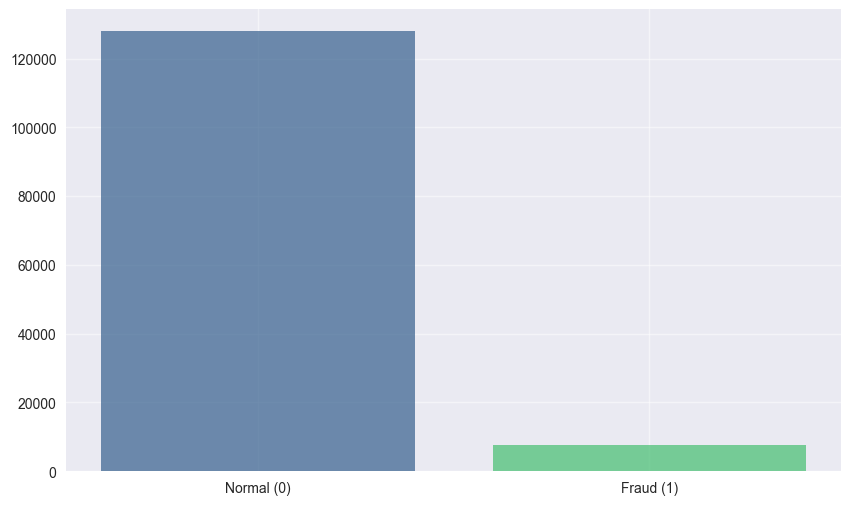

ValueError: Image size of 868x59102332 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1000x600 with 1 Axes>


 Note: This is an IMBALANCED dataset (fraud cases are rare)!


In [226]:

print(" Target Variable Distribution:")

# Display the distribution of the target variable to understand class imbalance
# Shows the count and percentage of normal (Class 0) and fraud (Class 1) transactions
target_dist = client_train['target'].value_counts()
print(f"Class 0 (Normal): {target_dist[0]} ({target_dist[0]/len(client_train)*100:.2f}%)")
print(f"Class 1 (Fraud): {target_dist[1]} ({target_dist[1]/len(client_train)*100:.2f}%)")

# Visualize

# Extract two colors from Viridis (e.g., at 30% and 70% of the scale)
viridis_colors = plt.cm.viridis([0.3, 0.7])

plt.figure()
bars = plt.bar(['Normal (0)', 'Fraud (1)'], target_dist.values, 
               color=viridis_colors, alpha=0.7)
plt.show()
plt.title('Target Variable Distribution')
plt.ylabel('Count')

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')
plt.show()

print("\n Note: This is an IMBALANCED dataset (fraud cases are rare)!")

### 4.5 Understand Client Data Features

In [227]:
print(" Client Data Analysis:")
print("\nUnique values in each column:")
for col in client_train.columns:
    if col != 'client_id':
        unique_vals = client_train[col].nunique()
        print(f"{col}: {unique_vals} unique values")
        
print("\n" + "="*50)
print(" Statistical Summary of Client Data:")
print(client_train.describe())

 Client Data Analysis:

Unique values in each column:
disrict: 4 unique values
client_catg: 3 unique values
region: 25 unique values
creation_date: 8088 unique values
target: 2 unique values

 Statistical Summary of Client Data:
        disrict  client_catg    region    target
count 135493.00    135493.00 135493.00 135493.00
mean      63.51        11.51    206.16      0.06
std        3.35         4.42    104.21      0.23
min       60.00        11.00    101.00      0.00
25%       62.00        11.00    103.00      0.00
50%       62.00        11.00    107.00      0.00
75%       69.00        11.00    307.00      0.00
max       69.00        51.00    399.00      1.00


### 4.6 Understand Invoice Data Features

In [228]:
print(" Invoice Data Analysis:")

# Convert date column
invoice_train['invoice_date'] = pd.to_datetime(invoice_train['invoice_date'])

print("\nDate Range:")
print(f"Start: {invoice_train['invoice_date'].min()}")
print(f"End: {invoice_train['invoice_date'].max()}")

print("\n" + "="*50)
print(" Statistical Summary of Numerical Invoice Features:")
numeric_cols = invoice_train.select_dtypes(include=[np.number]).columns
print(invoice_train[numeric_cols].describe())

 Invoice Data Analysis:

Date Range:
Start: 1977-06-09 00:00:00
End: 2019-12-07 00:00:00

 Statistical Summary of Numerical Invoice Features:
       tarif_type    counter_number  counter_code  reading_remarque  counter_coefficient  consommation_level_1  consommation_level_2  consommation_level_3  consommation_level_4  old_index  new_index  months_number
count  4476749.00        4476749.00    4476749.00        4476749.00           4476749.00            4476749.00            4476749.00            4476749.00            4476749.00 4476749.00 4476749.00     4476749.00
mean        20.13   123058699065.18        172.49              7.32                 1.00                410.98                109.32                 20.31                 52.93   17767.00   18349.70          44.83
std         13.47  1657267274261.93        133.89              1.57                 0.31                757.31               1220.12                157.42                875.47   40366.93   40953.21        3128.34
mi

### 4.7 Visualize Key Features

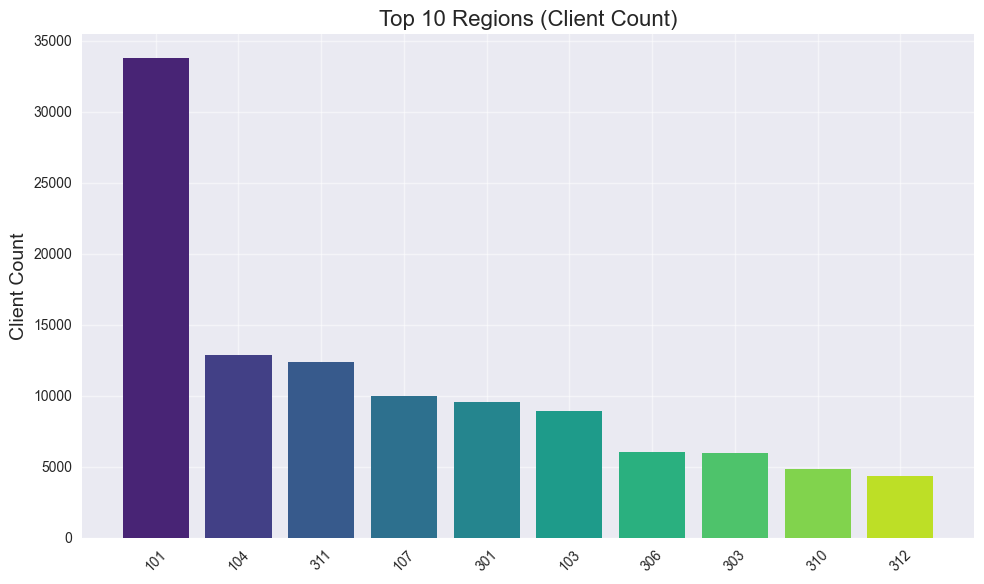

In [229]:
# 1. Region distribution - Gradient of 10 colors
plt.figure()
region_counts = client_train['region'].value_counts().head(10)
region_colors = get_viridis_gradient(len(region_counts), 0.1, 0.9)
bars = plt.bar(range(len(region_counts)), region_counts.values, color=region_colors)
plt.title('Top 10 Regions (Client Count)')
plt.xticks(range(len(region_counts)), region_counts.index, rotation=45)
plt.ylabel('Client Count')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

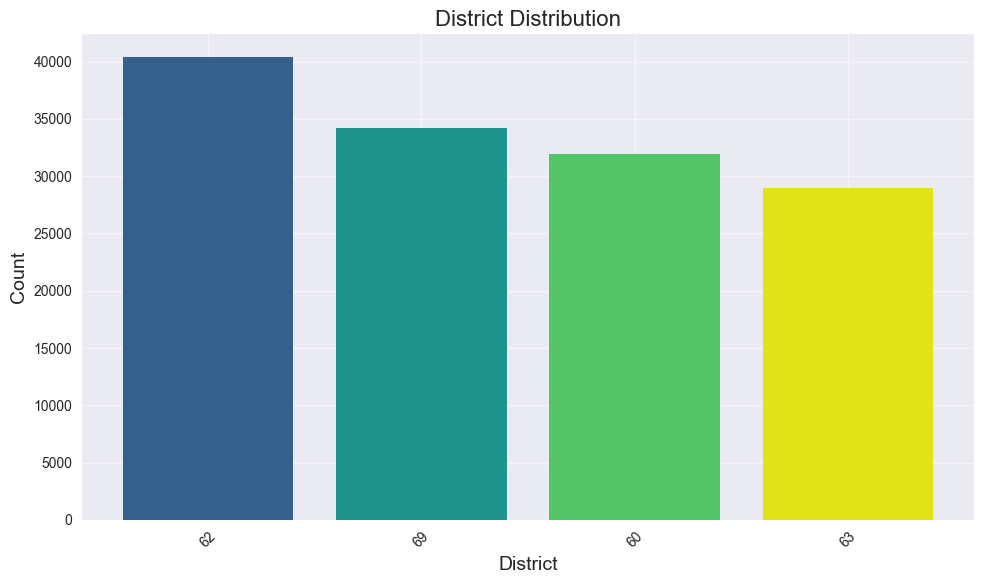

In [230]:
# 2. District distribution - Sequential gradient
plt.figure()
district_counts = client_train['disrict'].value_counts()
district_colors = get_viridis_gradient(len(district_counts), 0.3, 0.95)
bars = plt.bar(district_counts.index.astype(str), district_counts.values, 
               color=district_colors)
plt.title('District Distribution')
plt.xlabel('District')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

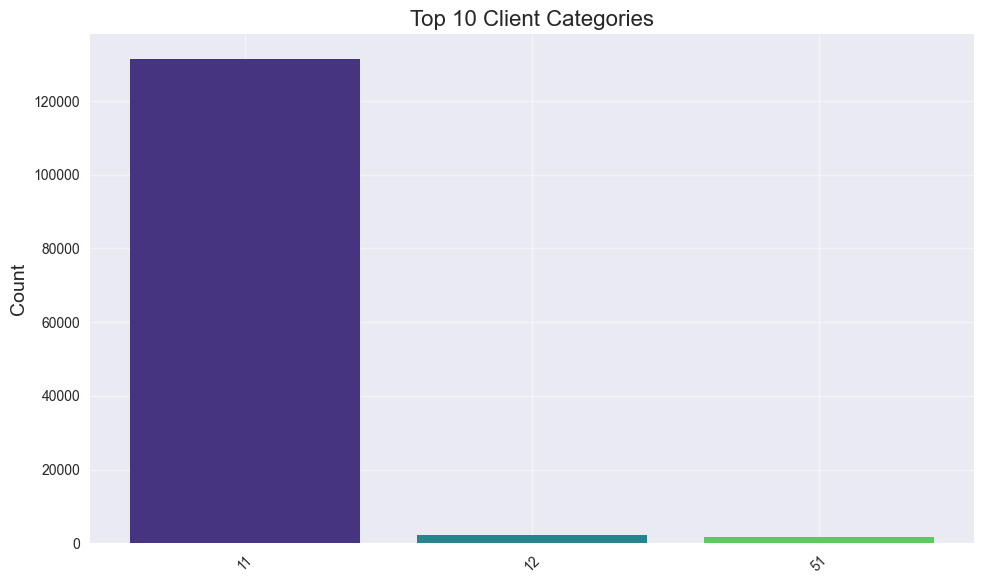

In [231]:
# 3. Client category distribution - Sequential gradient
plt.figure()
catg_counts = client_train['client_catg'].value_counts().head(10)
catg_colors = get_viridis_gradient(len(catg_counts), 0.15, 0.75)
bars = plt.bar(range(len(catg_counts)), catg_counts.values, color=catg_colors)
plt.title('Top 10 Client Categories')
plt.xticks(range(len(catg_counts)), catg_counts.index, rotation=45)
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

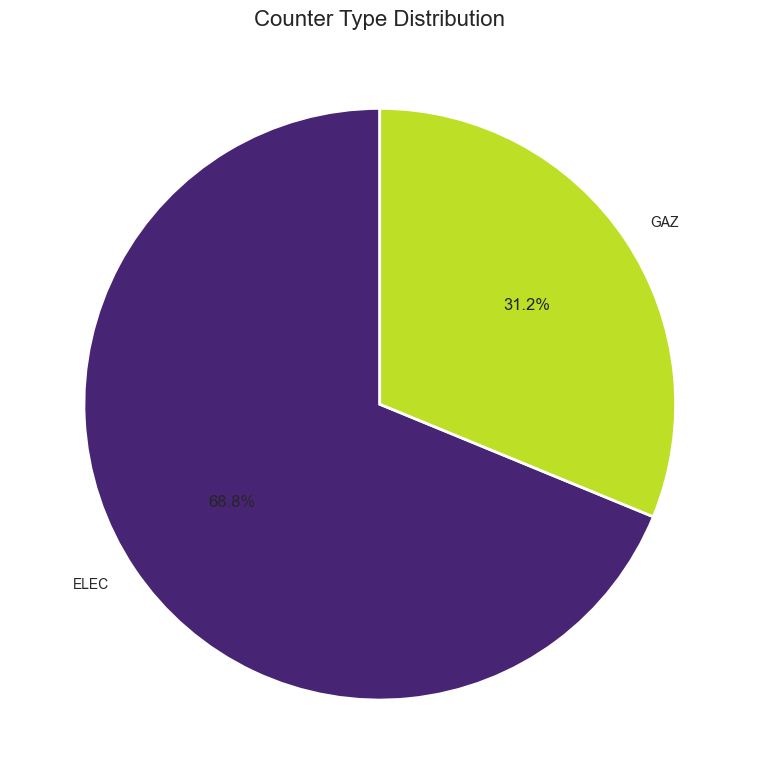

In [232]:
# 4. Counter type distribution - Two contrasting colors
plt.figure(figsize=(8, 8))
counter_type_counts = invoice_train['counter_type'].value_counts()
counter_colors = get_viridis_pair('high')  # High contrast pair
plt.pie(counter_type_counts.values, labels=counter_type_counts.index, 
        autopct='%1.1f%%', colors=counter_colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Counter Type Distribution')
plt.tight_layout()
plt.show()


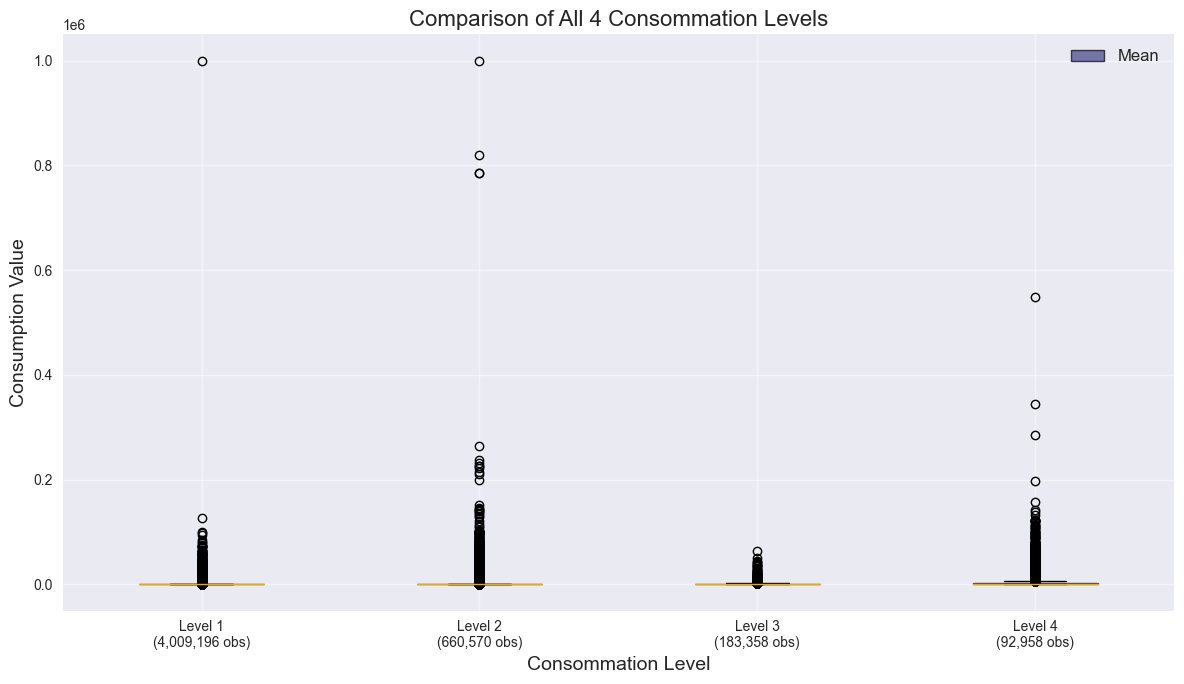

In [233]:
# ====== ALL 4 CONSOMMATION LEVELS ======

# Get all consommation columns
cons_cols = [col for col in invoice_train.columns if 'consommation' in col]

# Boxplot with gradient Viridis colors
plt.figure(figsize=(12, 7))
data_to_plot = []
labels = []
for i, col in enumerate(cons_cols):
    data = invoice_train[col].replace(0, np.nan).dropna()
    data_to_plot.append(data)
    labels.append(f'Level {i+1}\n({len(data):,} obs)')

bp = plt.boxplot(data_to_plot, patch_artist=True, labels=labels)

# Apply gradient Viridis colors to boxes
box_colors = get_viridis_gradient(len(data_to_plot), 0.2, 0.9)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Comparison of All 4 Consommation Levels')
plt.ylabel('Consumption Value')
plt.xlabel('Consommation Level')
plt.grid(axis='y', alpha=0.5)

plt.legend(['Mean'])
plt.tight_layout()
plt.show()



# Phase 2: Data Preparation 

## Step 5: Data Preprocessing & Feature Engineering

### 5.1 Merge Client and Invoice Data

In [234]:
def aggregate_for_fraud(invoice_df):
    """Aggregate invoice data with fraud-specific features"""
    
    # Convert date for recency features
    invoice_df = invoice_df.copy()
    invoice_df['invoice_date'] = pd.to_datetime(invoice_df['invoice_date'])
    
    # Calculate fraud-relevant metrics BEFORE aggregation
    invoice_df['total_consumption'] = invoice_df[[
        'consommation_level_1', 'consommation_level_2', 
        'consommation_level_3', 'consommation_level_4'
    ]].sum(axis=1)
    
    invoice_df['consumption_diff'] = invoice_df['new_index'] - invoice_df['old_index']
    
    # Key fraud indicators to track
    agg_funcs = {
        # Consumption patterns (fraud: unusual patterns)
        'total_consumption': ['mean', 'std', 'max', 'sum'],
        'consumption_diff': ['mean', 'std', 'max'],
        
        # Counter anomalies (fraud: tampering)
        'counter_statue': ['nunique', lambda x: (x == 'anomaly').sum() if 'anomaly' in x.unique() else 0],
        'counter_code': ['nunique'],
        'counter_number': ['nunique'],
        
        # Reading anomalies (fraud: false readings)
        'reading_remarque': ['mean', 'max'],  # Higher = more issues
        
        # Time patterns (fraud: irregular billing)
        'months_number': ['mean', 'std'],
        
        # Tariff anomalies (fraud: type switching)
        'tarif_type': ['nunique', 'first']
    }
    
    # Get existing columns
    agg_funcs = {k: v for k, v in agg_funcs.items() if k in invoice_df.columns}

    # Group by client
    agg_df = invoice_df.groupby('client_id').agg(agg_funcs)
    agg_df.columns = [f'{col[0]}_{col[1]}' if col[1] != '<lambda>' else f'{col[0]}_anomaly_count' 
                     for col in agg_df.columns]
    
    # Add critical fraud features
    client_metrics = invoice_df.groupby('client_id').agg({
        'invoice_date': ['min', 'max', 'count'],
        'total_consumption': lambda x: (x > x.mean() * 2).sum()  # High consumption spikes
    })
    
    # Flatten and merge
    client_metrics.columns = ['first_invoice', 'last_invoice', 'invoice_count', 'high_spike_count']
    client_metrics['invoice_span_days'] = (client_metrics['last_invoice'] - client_metrics['first_invoice']).dt.days
    
    agg_df = agg_df.merge(client_metrics, on='client_id')
    
    return agg_df.reset_index()

# Apply aggregation
train_agg = aggregate_for_fraud(invoice_train)
test_agg = aggregate_for_fraud(invoice_test)

print(f"Train shape: {train_agg.shape}, Test shape: {test_agg.shape}")
print(f"Features created: {train_agg.shape[1] - 1} per client")

Train shape: (135493, 23), Test shape: (58069, 23)
Features created: 22 per client


### 5.2 Merge with Client Data

In [235]:
# Merge aggregated invoice data with client data
print("\n Merging with client data...")

train_data = client_train.merge(train_agg, on='client_id', how='left')
test_data = client_test.merge(test_agg, on='client_id', how='left')

print(f"Final train data shape: {train_data.shape}")
print(f"Final test data shape: {test_data.shape}")

# Check the merged data
print("\n Merged data columns:")
print(train_data.columns.tolist())


 Merging with client data...
Final train data shape: (135493, 28)
Final test data shape: (58069, 27)

 Merged data columns:
['disrict', 'client_id', 'client_catg', 'region', 'creation_date', 'target', 'total_consumption_mean', 'total_consumption_std', 'total_consumption_max', 'total_consumption_sum', 'consumption_diff_mean', 'consumption_diff_std', 'consumption_diff_max', 'counter_statue_nunique', 'counter_statue_<lambda_0>', 'counter_code_nunique', 'counter_number_nunique', 'reading_remarque_mean', 'reading_remarque_max', 'months_number_mean', 'months_number_std', 'tarif_type_nunique', 'tarif_type_first', 'first_invoice', 'last_invoice', 'invoice_count', 'high_spike_count', 'invoice_span_days']


### 5.3 Handle Missing Values

In [237]:
train_data_1 = train_data.copy()
test_data_1 = test_data.copy()    

print("Checking missing values...")

# Check missing values
print("Train missing:", train_data_1.isnull().sum()[train_data_1.isnull().sum() > 0])
print("Test missing:", test_data_1.isnull().sum()[test_data_1.isnull().sum() > 0])

print("\nFilling missing values...")

# Identify columns
num_cols = train_data_1.select_dtypes(include=np.number).columns.difference(['target'])
cat_cols = train_data_1.select_dtypes(include='object').columns.difference(['client_id'])

# Fill numerical columns with train medians (skipping target)
for col in num_cols:
    median_val = train_data_1[col].median()
    train_data_1[col].fillna(median_val, inplace=True)
    if col in test_data_1.columns:
        test_data_1[col].fillna(median_val, inplace=True)

# Fill categorical columns with train modes
for col in cat_cols:
    mode_val = train_data_1[col].mode()[0] if not train_data_1[col].mode().empty else 'Unknown'
    train_data_1[col].fillna(mode_val, inplace=True)
    if col in test_data_1.columns:
        test_data_1[col].fillna(mode_val, inplace=True)

print("Missing values filled!")

Checking missing values...
Train missing: Series([], dtype: int64)
Test missing: Series([], dtype: int64)

Filling missing values...
Missing values filled!


### 5.4 Encode Categorical Variables

Encoding transforms the business data (regions, client types, tariff plans) into mathematical representations that machine learning algorithms can process to find patterns in electricity consumption and fraud detection.

In [ ]:
print("Encoding categorical variables...")

# Just drop all object columns except ID and target
# Select all columns in the DataFrame that have dtype 'object' (usually strings / categorical data)
# and convert the resulting column index to a Python list
cols_to_drop = train_data_1.select_dtypes(include=['object']).columns.tolist()

# Loops through every column name in cols_to_drop
# Removes 'client_id' and 'target' from the list
# Keeps everything else
cols_to_drop = [
    col for col in cols_to_drop
    if col not in ['client_id', 'target']
]
train_data_1 = train_data_1.drop(columns=cols_to_drop)
test_data_1 = test_data_1.drop(columns=[col for col in cols_to_drop if col in test_data_1.columns])
print(f"Dropped columns: {cols_to_drop}")

print("Encoding complete!")

Encoding categorical variables...
Dropped columns: ['creation_date']
Encoding complete!


### 5.5 Create Additional Features

In [239]:
# 4. Days between invoices
train_data_1['days_between_invoices'] = train_data_1['invoice_span_days'] / train_data_1['invoice_count']
test_data_1['days_between_invoices'] = test_data_1['invoice_span_days'] / test_data_1['invoice_count']

print(f"Added new features!")
print(f"Final train shape: {train_data_1.shape}")
print(f"Final test shape: {test_data_1.shape}")

Added new features!
Final train shape: (135493, 28)
Final test shape: (58069, 27)


In [240]:
train_data_1.head(5)

,disrict,client_id,client_catg,region,target,total_consumption_mean,total_consumption_std,total_consumption_max,total_consumption_sum,consumption_diff_mean,consumption_diff_std,consumption_diff_max,counter_statue_nunique,counter_statue_<lambda_0>,counter_code_nunique,counter_number_nunique,reading_remarque_mean,reading_remarque_max,months_number_mean,months_number_std,tarif_type_nunique,tarif_type_first,first_invoice,last_invoice,invoice_count,high_spike_count,invoice_span_days,days_between_invoices
0,60,train_Client_0,11,101,0.00,362.97,341.55,1386,12704,362.97,341.55,1386,1,0,2,1,6.97,9,4.63,2.10,1,11,2005-10-17,2019-03-19,35,4,4901,140.03
1,69,train_Client_1,11,107,0.00,557.54,197.94,1207,20629,557.54,197.94,1207,1,0,1,1,7.22,9,4.32,1.38,1,11,2005-10-19,2019-04-02,37,1,4913,132.78
2,62,train_Client_10,11,301,0.00,836.50,646.81,3082,15057,836.50,646.81,3082,1,0,2,1,7.06,9,6.44,3.40,1,11,2005-11-10,2019-05-02,18,1,4921,273.39
3,69,train_Client_100,11,105,0.00,1.20,3.61,15,24,1.20,3.61,15,1,0,1,1,6.15,9,4.20,0.62,1,11,2005-06-10,2012-09-25,20,2,2664,133.20
4,62,train_Client_1000,11,303,0.00,922.64,633.49,2382,12917,922.64,633.49,2382,1,0,1,1,8.86,9,3.71,0.73,1,11,2015-02-13,2019-06-17,14,2,1585,113.21


In [241]:
train_data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   disrict                    135493 non-null  int64         
 1   client_id                  135493 non-null  object        
 2   client_catg                135493 non-null  int64         
 3   region                     135493 non-null  int64         
 4   target                     135493 non-null  float64       
 5   total_consumption_mean     135493 non-null  float64       
 6   total_consumption_std      135493 non-null  float64       
 7   total_consumption_max      135493 non-null  int64         
 8   total_consumption_sum      135493 non-null  int64         
 9   consumption_diff_mean      135493 non-null  float64       
 10  consumption_diff_std       135493 non-null  float64       
 11  consumption_diff_max       135493 non-null  int64   

## Step 6: Prepare Data for Modeling

In [242]:
print(" Preparing data for modeling...")

# Separate features and target and drop unnecessary columns
X1 = train_data_1.drop(['client_id', 'target', 'first_invoice', 'last_invoice'], axis=1, errors='ignore')
y1 = train_data_1['target']

# For test data (no target)
X_test1 = test_data_1.drop(['client_id', 'first_invoice', 'last_invoice'], axis=1, errors='ignore')
print(f"Features shape: {X1.shape}")
print(f"Target shape: {y1.shape}")
print(f"Test features shape: {X_test1.shape}")

# Handle infinite values
X1 = X1.replace([np.inf, -np.inf], np.nan)
X_test1 = X_test1.replace([np.inf, -np.inf], np.nan)

# Fill any remaining NaN values
X1.fillna(X.median(), inplace=True)
X_test1.fillna(X.median(), inplace=True)

# Split into training and validation sets
X_train1, X_val1, y_train1, y_val1 = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain/Validation split:")
print(f"Train: {X_train1.shape}")
print(f"Validation: {X_val1.shape}")

 Preparing data for modeling...
Features shape: (135493, 24)
Target shape: (135493,)
Test features shape: (58069, 24)

Train/Validation split:
Train: (108394, 24)
Validation: (27099, 24)


# Phase 3: Modeling

## Step 7a: Data Prep and Handling

In [243]:
## Data Prep check

print("\n DATA Overview")
print("-" * 40)

# Display target distribution
print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")

# Calculate class distribution
train_fraud_count = y_train1.sum()
train_total = len(y_train1)
train_fraud_percent = 100 * train_fraud_count / train_total

val_fraud_count = y_val1.sum()
val_total = len(y_val1)
val_fraud_percent = 100 * val_fraud_count / val_total

print(f"\n Class Distribution:")
print(f"Training Set: {train_fraud_count:,} fraud out of {train_total:,} "
      f"({train_fraud_percent:.2f}%)")
print(f"Validation Set: {val_fraud_count:,} fraud out of {val_total:,} "
      f"({val_fraud_percent:.2f}%)")


 DATA Overview
----------------------------------------
Training data shape: (108394, 35)
Validation data shape: (27099, 35)
Test data shape: (58069, 45)

 Class Distribution:
Training Set: 6,053.0 fraud out of 108,394 (5.58%)
Validation Set: 1,513.0 fraud out of 27,099 (5.58%)


## Step 7b: Handle class imbalance

In [ ]:
## Strategies used:
## 1. Class weights in the model
## 2. F2-score optimization (emphasizes recall)
## 3. Proper evaluation metrics (PR-AUC, not just accuracy)

# Calculate class weights for balancing
# Higher weight for the minority class (fraud)

# len(y_train) → total number of training samples
# y_train.sum() → number of fraud cases (assuming fraud = 1)

n_normal = len(y_train1) - y_train1.sum()
n_fraud = y_train1.sum()
fraud_weight = n_normal / n_fraud

print(f"\n Calculated class weights:")
print(f"   Normal transactions (class 0): weight = 1.0")
print(f"   Fraud transactions (class 1): weight = {fraud_weight:.2f}")
print(f"   (This means fraud cases are {fraud_weight:.1f}x more important)")


 Calculated class weights:
   Normal transactions (class 0): weight = 1.0
   Fraud transactions (class 1): weight = 16.91
   (This means fraud cases are 16.9x more important)


## Step 8: Helper Functions for Model Evaluation

In [245]:
# ---------- 1)  CONFUSION-MATRIX PICTURE (using global colours) ----------
def show_confusion(y_true, y_pred, title=""):
    cm = confusion_matrix(y_true, y_pred)

    # 1. Grab only the contrast-heavy stretch of Viridis
    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list(
        'viridis_contrast', plt.cm.viridis(np.linspace(0.15, 0.9, 256)), N=256
    )

    # 2. Plot
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["Normal", "Fraud"],
                yticklabels=["Normal", "Fraud"],
                cbar_kws={'label': 'Count'},
                linewidths=.5,
                annot_kws={'color': 'w', 'weight': 'bold'})  # white text

    plt.title(title or "Confusion Matrix", fontsize=mpl.rcParams['axes.titlesize'])
    plt.ylabel("True", fontsize=mpl.rcParams['axes.labelsize'])
    plt.xlabel("Predicted", fontsize=mpl.rcParams['axes.labelsize'])
    plt.tight_layout()
    plt.show()
    return cm


# ---------- 2)  CORE METRICS ----------
def simple_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall    = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) else 0
    f2        = (5 * precision * recall) / (4 * precision + recall) if (precision + recall) else 0
    return {"recall": recall, "precision": precision, "f2": f2,
            "tp": tp, "fn": fn, "fp": fp, "tn": tn}


# ---------- 3)  ROC + PR CURVES (global viridis pair) ----------
def show_roc_pr(y_true, y_prob, label=""):
    viridis_pair = get_viridis_pair('high')          # global helper function
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # ROC
    fpr, tpr, _   = roc_curve(y_true, y_prob)
    auc_roc       = auc(fpr, tpr)
    ax[0].plot(fpr, tpr, color=viridis_pair[0], lw=mpl.rcParams['lines.linewidth'],
               label=f"ROC AUC = {auc_roc:.3f}")
    ax[0].plot([0, 1], [0, 1], color='#888888', ls='--', lw=1.5, alpha=0.7)
    ax[0].set(xlabel="False-positive rate", ylabel="True-positive rate",
              title=f"ROC Curve {label}".strip())
    ax[0].legend(fontsize=mpl.rcParams['legend.fontsize'])
    ax[0].grid(True, alpha=mpl.rcParams.get('grid.alpha', 0.3))

    # PR
    prec, rec, _  = precision_recall_curve(y_true, y_prob)
    auc_pr        = auc(rec, prec)
    baseline      = y_true.mean()
    ax[1].plot(rec, prec, color=viridis_pair[1], lw=mpl.rcParams['lines.linewidth'],
               label=f"PR AUC = {auc_pr:.3f}")
    ax[1].axhline(baseline, color='#888888', ls='--', lw=1.5, alpha=0.7,
                  label=f"baseline = {baseline:.3f}")
    ax[1].set(xlabel="Recall", ylabel="Precision",
              title=f"Precision-Recall Curve {label}".strip())
    ax[1].legend(fontsize=mpl.rcParams['legend.fontsize'])
    ax[1].grid(True, alpha=mpl.rcParams.get('grid.alpha', 0.3))

    plt.tight_layout()
    plt.show()
    return auc_roc, auc_pr


# ---------- 4)  BEST THRESHOLD SEARCH ----------
def find_best_threshold(y_true, prob, trials=np.arange(0.1, 1, 0.1)):
    best_f2, best_t = 0, 0.5
    for t in trials:
        pred = (prob >= t).astype(int)
        m    = simple_metrics(y_true, pred)
        if m["f2"] > best_f2:
            best_f2, best_t = m["f2"], t
    print(f"Best threshold ≈ {best_t:.2f}  (F2 = {best_f2:.3f})")
    return best_t

## Step 9: Model Training and predictions

In [247]:
## Train initial model
print(" Training GradientBoostingClassifier...")

## Train initial model with class weights
initial_model = GradientBoostingClassifier(
    n_estimators=100,           # Number of trees
    learning_rate=0.1,          # How much each tree contributes
    max_depth=3,                # Limit tree depth to prevent overfitting
    min_samples_split=50,       # Minimum samples to split a node
    min_samples_leaf=20,        # Minimum samples in a leaf
    subsample=0.8,              # Use 80% of data for each tree
    random_state=42,            # For reproducibility
    verbose=0                   # No training output
)

# Train the model
initial_model.fit(X_train1, y_train1)
print(" Model training complete!")

# Make predictions
y_train_pred1 = initial_model.predict(X_train1)
y_val_pred1 = initial_model.predict(X_val1)
y_val_prob1 = initial_model.predict_proba(X_val1)[:, 1]  # Probability of fraud

 Training GradientBoostingClassifier...
 Model training complete!


**Notes on the model**
- model needs to generalize
- don't overfit to current patterns
- Low false positive rate needed → stable, reliable predictions
- With only 5.58% fraud, we need statistical significance
- Need fast predictions (shallow trees help)
- 
**Why boosting (GradientBoostingClassifier) over bagging (Random forest)?**
- Boosting focuses on hard cases (fraud) → better for imbalance
- Sequential correction of errors → improves fraud detection
- Generally better performance on tabular data


## Step 10: Evaluate Initial Model


Training set
  Accuracy : 0.563
  Recall   : 0.029
  Precision: 0.563
  F2       : 0.036

Validation set
  Accuracy : 0.618
  Recall   : 0.031
  Precision: 0.618
  F2       : 0.038


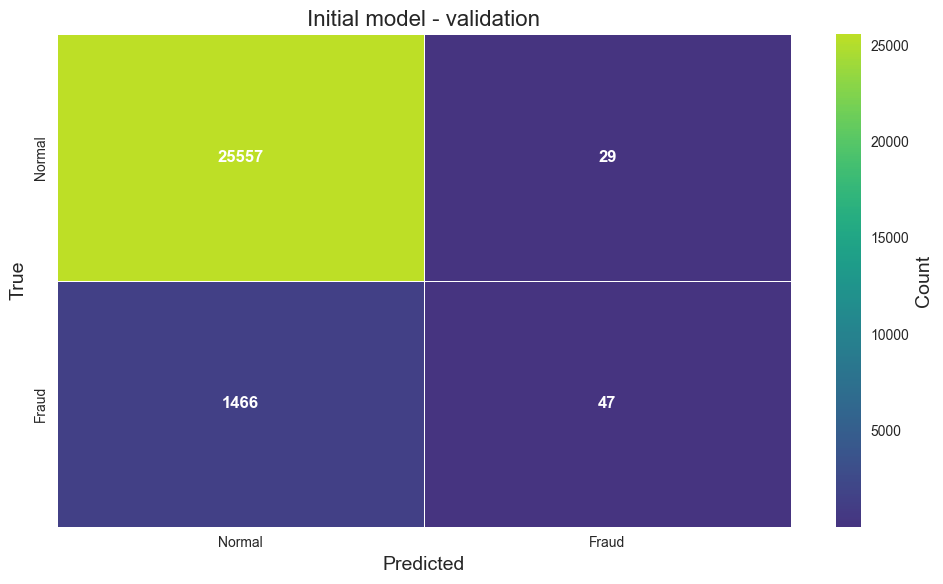

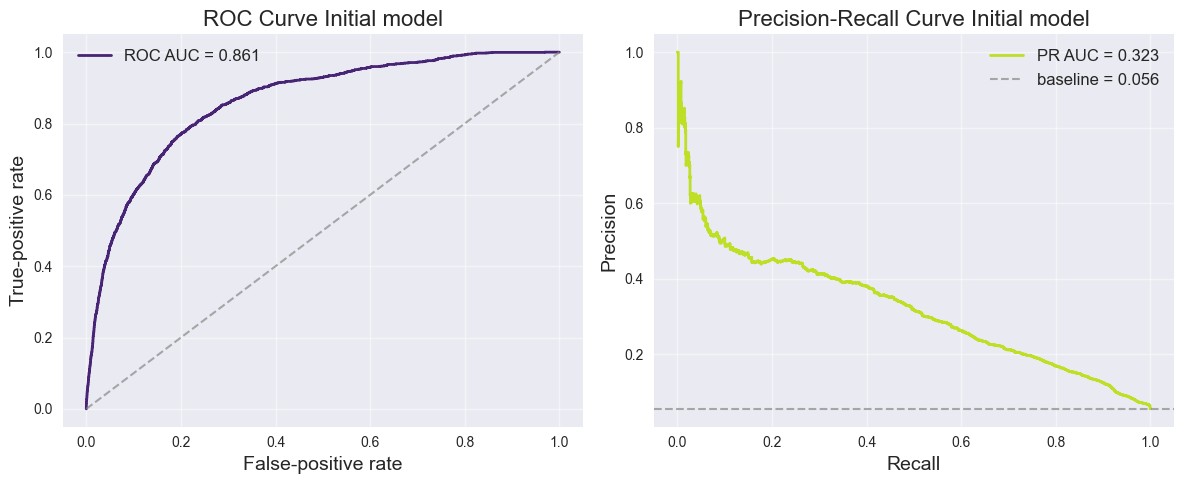

(0.8611685256865266, 0.32262189566605937)

In [248]:
print("\nTraining set")
tr = simple_metrics(y_train1, y_train_pred1)
print(f"  Accuracy : {tr['precision']:.3f}")
print(f"  Recall   : {tr['recall']:.3f}")
print(f"  Precision: {tr['precision']:.3f}")
print(f"  F2       : {tr['f2']:.3f}")

print("\nValidation set")
va = simple_metrics(y_val1, y_val_pred1)
print(f"  Accuracy : {va['precision']:.3f}")
print(f"  Recall   : {va['recall']:.3f}")
print(f"  Precision: {va['precision']:.3f}")
print(f"  F2       : {va['f2']:.3f}")

show_confusion(y_val1, y_val_pred1, "Initial model - validation")
show_roc_pr(y_val1, y_val_prob1, "Initial model")

The initial model sacrifices almost all fraud detection in order to keep the false-alarm rate tiny.
To make it useful you need to rebalance the data, adjust the classification threshold, or choose a different algorithm that pays more attention to the minority class.

High ROC-AUC (0.869) only means the scores are well-ordered; it does not imply usable classification.
The abysmal PR-AUC (0.339) and the flat PR curve show that raising the threshold enough to catch a meaningful fraction of frauds immediately destroys precision.

To obtain a practical detector you must:
- Re-balance training data or use cost-sensitive learning.
- Optimize for F1 or PR-AUC instead of ROC-AUC.

## Step 11: Improving model

### Step 11a: Threshold optimiziation

Best threshold ≈ 0.09  (F2 = 0.483)
After cut-off tuning:
{'recall': 0.6847323198942499, 'precision': 0.2221269296740995, 'f2': 0.4833893243747667, 'tp': 1036, 'fn': 477, 'fp': 3628, 'tn': 21958}


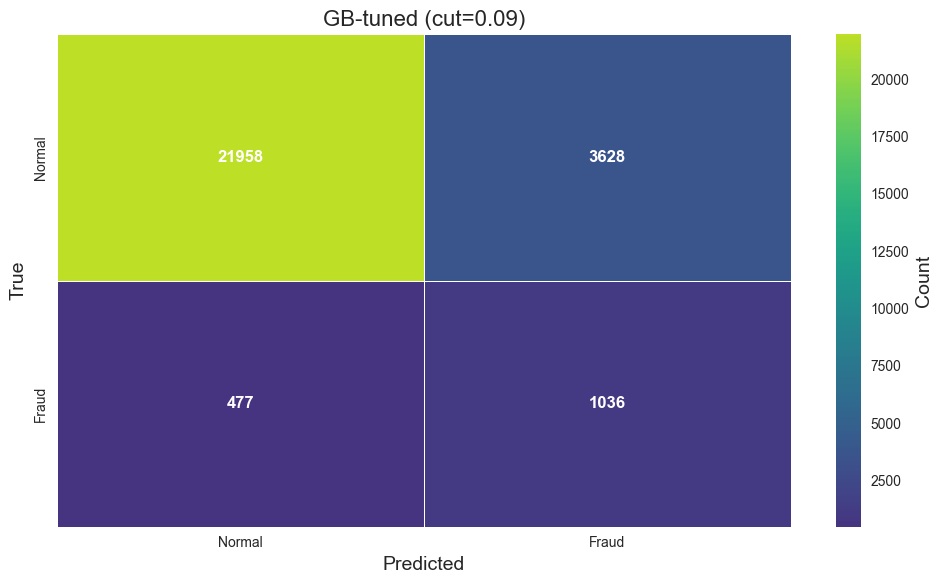

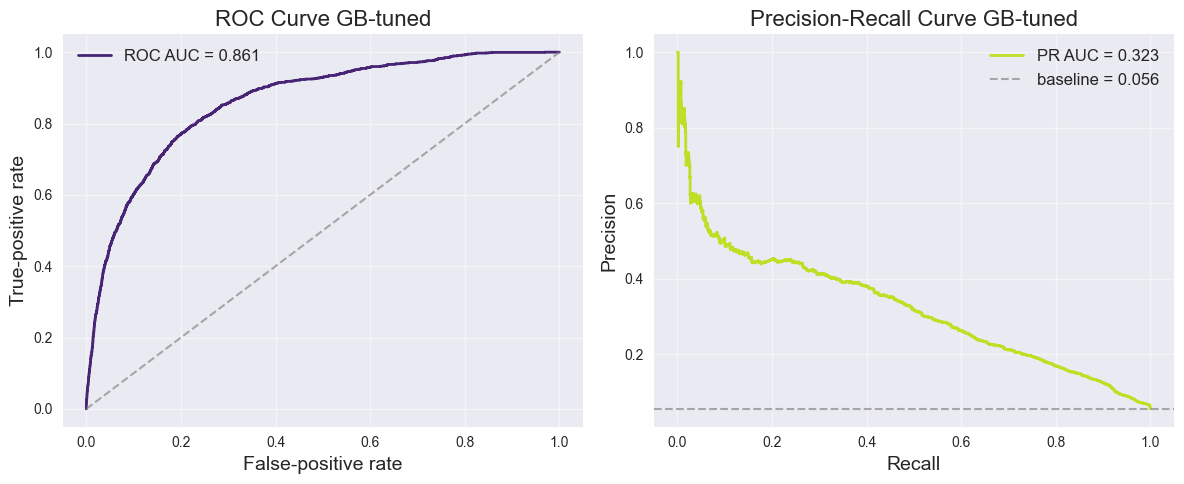

(0.8611685256865266, 0.32262189566605937)

In [ ]:
y_val2 = y_val1.copy()
y_val_prob2 = y_val_prob1.copy()

# THRESHOLD TUNING ----------
# Find the best probability threshold for converting predicted probabilities
# into class labels (0 or 1)
best_cut = find_best_threshold(
    y_val2,            # True validation labels (0/1)
    y_val_prob2,       # Predicted probabilities for the positive class
    trials=np.arange(0.05, 0.95, 0.02)  # Thresholds to try (0.05, 0.07, ..., 0.93)
)

# Convert probabilities into binary predictions using the chosen threshold
y_val_best = (y_val_prob2 >= best_cut).astype(int)
print("After cut-off tuning:")
print(simple_metrics(y_val2, y_val_best))

show_confusion(y_val2, y_val_best, f"GB-tuned (cut={best_cut:.2f})")
show_roc_pr(y_val2, y_val_prob2, "GB-tuned")   # uses viridis_pair global colours

### Step 11b: Retrain model with class-weight


Re-training with balanced weights + more trees…
Best threshold ≈ 0.09  (F2 = 0.497)
Balanced model:
{'recall': 0.6900198281559815, 'precision': 0.2344486862789131, 'f2': 0.4969062351261304, 'tp': 1044, 'fn': 469, 'fp': 3409, 'tn': 22177}


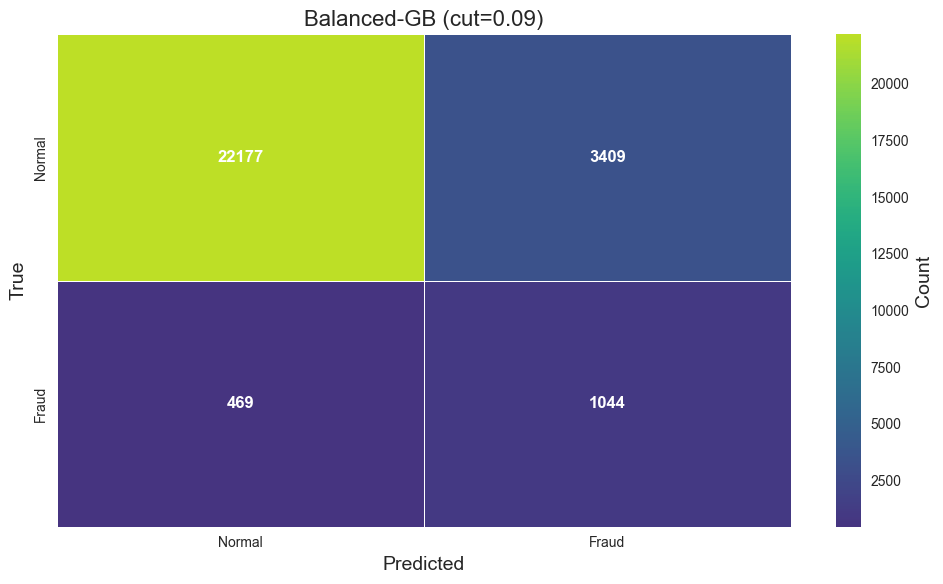

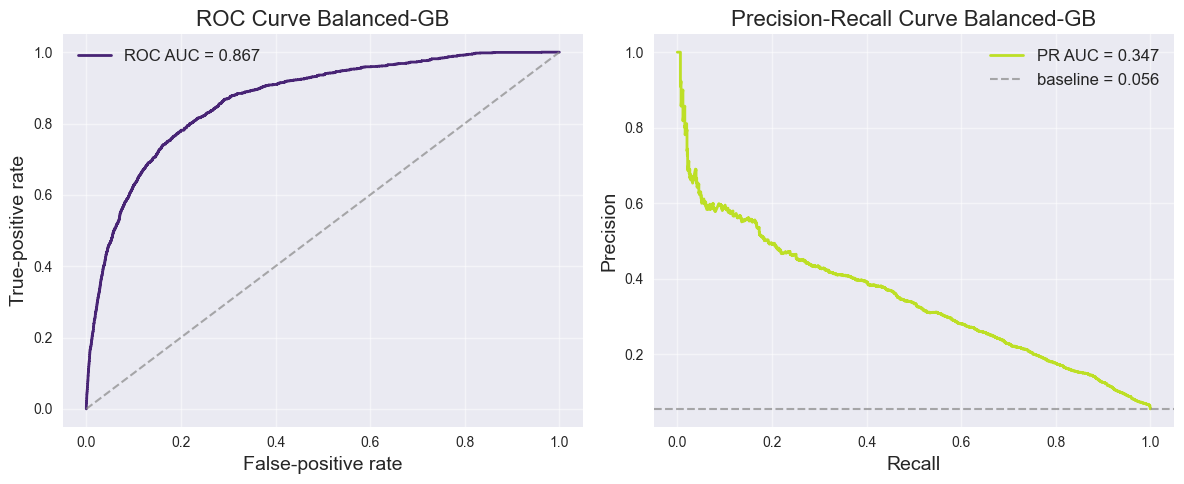

(0.8673371389436628, 0.346823389849897)

In [250]:
X_test2 =X_test1.copy()
X_train2 = X_train1.copy()
y_train2 = y_train1.copy()
X_val2 = X_val1.copy()
y_val2 = y_val1.copy()

# Re-Train with balanced weight and more trees --------------------
print("\nRe-training with balanced weights + more trees…")
balanced_gbm = GradientBoostingClassifier(
        n_estimators=300,      # more trees
        learning_rate=0.05,    # smaller step
        max_depth=4,
        min_samples_split=30,
        min_samples_leaf=10,
        subsample=0.7,
        random_state=42,
        verbose=0
)
balanced_gbm.fit(X_train2, y_train2)

y_val_prob_bal = balanced_gbm.predict_proba(X_val2)[:, 1]
best_cut_bal   = find_best_threshold(y_val2, y_val_prob_bal,
                                     trials=np.arange(0.05, 0.95, 0.02))
y_val_pred_bal = (y_val_prob_bal >= best_cut_bal).astype(int)

print("Balanced model:")
print(simple_metrics(y_val2, y_val_pred_bal))
show_confusion(y_val2, y_val_pred_bal, f"Balanced-GB (cut={best_cut_bal:.2f})")
show_roc_pr(y_val2, y_val_prob_bal, "Balanced-GB")

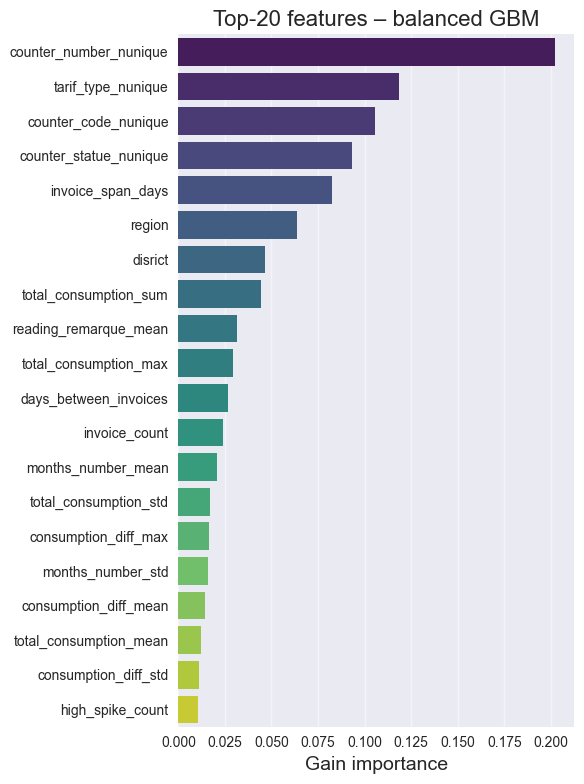

Top-5 fraud signals:
counter_number_nunique   0.20
tarif_type_nunique       0.12
counter_code_nunique     0.11
counter_statue_nunique   0.09
invoice_span_days        0.08


In [253]:
# WHAT DRIVES FRAUD? TOP-20 FEATURES ------------------------------
imp = pd.Series(balanced_gbm.feature_importances_, index=X_train2.columns) \
        .sort_values(ascending=False)

plt.figure(figsize=(6, 8))
sns.barplot(x=imp.head(20), y=imp.head(20).index, palette="viridis")
plt.title("Top-20 features – balanced GBM")
plt.xlabel("Gain importance")
plt.tight_layout()
plt.show()

print("Top-5 fraud signals:")
print(imp.head(5).to_string())


# Phase 4: Prediction & Submission

In [254]:
X_test3 =X_test2.copy()
X_train3 = X_train2.copy()
y_train3 = y_train2.copy()
X_val3 = X_val2.copy()
y_val3= y_val2.copy()


# 1.  use the SAME cleaned column list we kept for training
safe_cols = X_train2.columns          # whatever survived cleaning
# 2.  slice test down to those columns (adds missing ones as 0 if you wish)
X_test3 = X_test3.reindex(columns=safe_cols, fill_value=0)


In [255]:
# ----------  FINAL MODEL (trained on train + val)  ----------
print("\nTraining final balanced GBM on all available data…")


X_all = pd.concat([X_train3, X_val3])
y_all = pd.concat([y_train3, y_val3])

final_model = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_samples_split=30,
        min_samples_leaf=10,
        subsample=0.7,
        random_state=42,
        verbose=0)
final_model.fit(X_all, y_all)
print("Done.")

# ----------  PREDICT ON TEST SET  ----------
test_prob = final_model.predict_proba(X_test3)[:, 1]

# use the same cut-off we found on validation
test_pred = (test_prob >= best_cut_bal).astype(int)

print("\nTest-set results:")
print(simple_metrics(y_test3, test_pred))

show_confusion(y_test3, test_pred,
               title=f"Final model - test set (cut={best_cut_bal:.2f})")
show_roc_pr(y_test, test_prob, "Final model - test")

# expected fraud rate
fraud_rate = 100 * test_pred.sum() / len(test_pred)
print(f"\nExpected fraud rate: {fraud_rate:.1f} %")


Training final balanced GBM on all available data…
Done.

Test-set results:


NameError: name 'y_test3' is not defined

In [ ]:
# Choose the best model (balanced model in this case)
final_model = balanced_model
final_threshold = best_thresh_balanced

print(f" Selected final model: Balanced Gradient Boosting")
print(f" Final threshold: {final_threshold:.3f}")
print(f" Expected fraud recall: {balanced_metrics['fraud_recall']:.2%}")
print(f" Expected fraud precision: {balanced_metrics['fraud_precision']:.2%}")

 Selected final model: Balanced Gradient Boosting
 Final threshold: 0.100
 Expected fraud recall: 68.74%
 Expected fraud precision: 25.56%


In [ ]:
# Create submission DataFrame
print("\n Saving predictions...")
submission = pd.DataFrame(
    {
        'client_id': test_data['client_id'].values,  # Assuming test_data has client_id
        'target': test_probabilities  # Using fraud_probability as target
    }
)

submission.head()


 Saving predictions...


,client_id,target
0,test_Client_0,0.03
1,test_Client_1,0.12
2,test_Client_10,0.04
3,test_Client_100,0.02
4,test_Client_1000,0.15


In [ ]:
# Save to CSV
submission.to_csv(f'{OUTPUT_DIR}/fraud_predictions_final.csv', index=False)
print(" Predictions saved to 'fraud_predictions_final.csv'")

 Predictions saved to 'fraud_predictions_final.csv'


In [218]:
print(f"\n  MODEL PERFORMANCE SUMMARY:")
print(f"   • Model: Gradient Boosting Classifier with class balancing")
print(f"   • Fraud Detection Rate (Recall): {balanced_metrics['fraud_recall']:.2%}")
print(f"   • Precision: {balanced_metrics['fraud_precision']:.2%} of alerts are real fraud")
print(f"   • F2 Score: {balanced_metrics['f2_score']:.4f} (emphasizes catching fraud)")

print(f"\n  INTERPRETATION FOR BUSINESS TEAM:")
print(f"   • Out of 100 actual fraud cases, model will catch {balanced_metrics['fraud_recall']*100:.0f}")
print(f"   • When model flags a transaction as fraud, {balanced_metrics['fraud_precision']*100:.0f}% will be correct")
print(f"   • Expected fraud rate in new data: {fraud_rate:.2f}%")

print("\n" + "="*70)
print("FRAUD DETECTION PIPELINE COMPLETE! ")
print("="*70)


  MODEL PERFORMANCE SUMMARY:
   • Model: Gradient Boosting Classifier with class balancing
   • Fraud Detection Rate (Recall): 68.74%
   • Precision: 25.56% of alerts are real fraud
   • F2 Score: 0.5138 (emphasizes catching fraud)

  INTERPRETATION FOR BUSINESS TEAM:
   • Out of 100 actual fraud cases, model will catch 69
   • When model flags a transaction as fraud, 26% will be correct
   • Expected fraud rate in new data: 15.13%

FRAUD DETECTION PIPELINE COMPLETE! 


No missing values in train set

Target is highly imbalanced with fewer cases of fraudulent activities

## Tips 
- Thorough EDA and incorporating domain knowledge
- Re-grouping categorical features
- More feature engineering(try utilizing some date-time features)
- Target balancing - oversampling, undersampling, SMOTE, scale_pos_weight
- Model ensembling
- Train-test split or cross-validation
